# Novel Data — Analysis Notebook

Interactive version of `analyse_processed_data.py`. Reads `PROCESSED_DATA.csv` and produces the two required chart outputs (`decade_releases.png`, `top_authors.png`), plus inline exploratory views.

## 1. Set Up Environment and Load Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Plotting defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_ROOT = Path(".")
CSV_PATH = PROJECT_ROOT / "PROCESSED_DATA.csv"
REQUIRED_COLUMNS = {"title", "author_name", "year", "rating", "ratings"}

df = pd.read_csv(CSV_PATH)

missing = REQUIRED_COLUMNS.difference(df.columns)
if missing:
    raise ValueError(f"PROCESSED_DATA.csv missing columns: {sorted(missing)}")

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

Loaded 982 rows, 5 columns


,title,author_name,year,rating,ratings
0,Heartstopper: Volume Four,Alice Oseman,2021,4.67,227360
1,It Starts with Us,Colleen Hoover,2022,4.64,3988
2,Heartstopper: Volume Three,Alice Oseman,2020,4.63,273686
3,Kingdom of Ash,Sarah J. Maas,2018,4.62,261600
4,Crooked Kingdom,Leigh Bardugo,2016,4.61,477098


## 2. Data Quality Checks

In [2]:
print("=== Schema ===")
print(df.dtypes)
print("\n=== Null counts ===")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nYear range: {df['year'].min()} – {df['year'].max()}")
print(f"Rating range: {df['rating'].min()} – {df['rating'].max()}")
print(f"Ratings range: {df['ratings'].min():,} – {df['ratings'].max():,}")

=== Schema ===
title              str
author_name        str
year             int64
rating         float64
ratings          int64
dtype: object

=== Null counts ===
title          0
author_name    0
year           0
rating         0
ratings        0
dtype: int64

Duplicate rows: 0

Year range: 1595 – 2022
Rating range: 3.39 – 4.67
Ratings range: 3,988 – 7,591,926


## 3. Clean and Transform Variables

In [3]:
# Cast numeric columns, coerce bad values to NaN
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["ratings"] = pd.to_numeric(df["ratings"], errors="coerce")

# Derive decade for grouping
df["decade"] = (df["year"].dropna().astype(int) // 10 * 10)

print(f"Rows after cast: {len(df):,}")
print(f"Rows with valid year: {df['year'].notna().sum():,}")
print(f"Rows with valid ratings: {df['ratings'].notna().sum():,}")
df.dtypes

Rows after cast: 982
Rows with valid year: 982
Rows with valid ratings: 982


title              str
author_name        str
year             int64
rating         float64
ratings          int64
decade           int64
dtype: object

## 4. Descriptive Statistics

In [4]:
df[["year", "rating", "ratings"]].describe()

,year,rating,ratings
count,982.000000,982.000000,9.820000e+02
mean,2008.848269,4.032658,1.788003e+05
std,26.994174,0.215075,4.102444e+05
min,1595.000000,3.390000,3.988000e+03
25%,2009.000000,3.890000,3.472275e+04
50%,2013.000000,4.040000,6.504550e+04
75%,2018.000000,4.170000,1.567812e+05
max,2022.000000,4.670000,7.591926e+06


In [5]:
print("=== Books per decade ===")
print(df["decade"].value_counts().sort_index())
print("\n=== Top 10 most-prolific authors (book count) ===")
print(df["author_name"].value_counts().head(10))

=== Books per decade ===
decade
1590      2
1810      4
1840      1
1850      1
1870      1
1890      1
1900      1
1920      4
1930      2
1940      2
1950      6
1960      1
1970      3
1980     13
1990     44
2000    185
2010    552
2020    159
Name: count, dtype: int64

=== Top 10 most-prolific authors (book count) ===
author_name
Nora Roberts              38
Lisa Kleypas              22
Julia Quinn               20
Colleen Hoover            17
Kristen Ashley            14
Sarah J. Maas             13
Jennifer L. Armentrout    13
Nicholas Sparks           12
Tessa Dare                11
Sarah MacLean             11
Name: count, dtype: int64


## 5. Relationships and Correlations

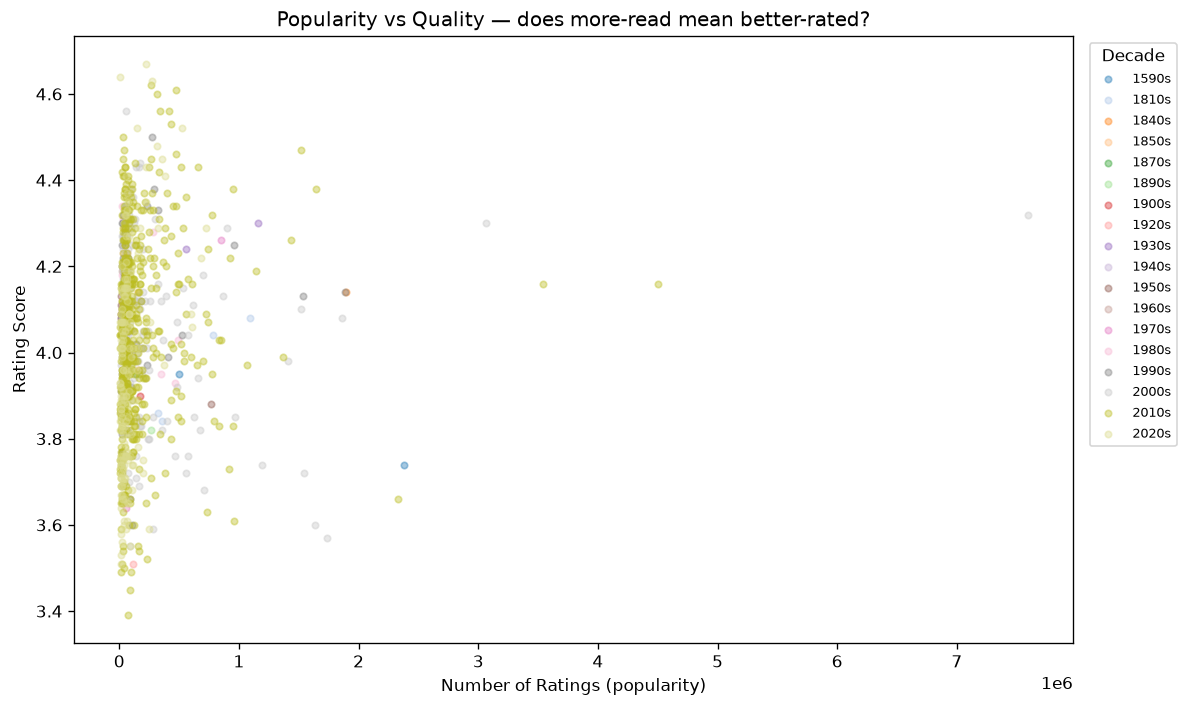

Pearson r (ratings vs rating): 0.075


In [6]:
scatter_df = df.dropna(subset=["ratings", "rating", "decade"]).copy()

decades_sorted = sorted(scatter_df["decade"].unique())
colours = plt.cm.tab20.colors
decade_colour = {d: colours[i % len(colours)] for i, d in enumerate(decades_sorted)}

fig, ax = plt.subplots(figsize=(10, 6))
for decade, group in scatter_df.groupby("decade"):
    ax.scatter(
        group["ratings"],
        group["rating"],
        alpha=0.4,
        s=15,
        color=decade_colour[decade],
        label=f"{int(decade)}s",
    )

ax.set_xlabel("Number of Ratings (popularity)")
ax.set_ylabel("Rating Score")
ax.set_title("Popularity vs Quality — does more-read mean better-rated?")
ax.legend(title="Decade", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

corr_val = scatter_df[["ratings", "rating"]].corr().iloc[0, 1]
print(f"Pearson r (ratings vs rating): {corr_val:.3f}")

## 6. Grouped and Decade-Based Summaries

In [7]:
decade_summary = (
    df.dropna(subset=["decade"])
    .groupby("decade")
    .agg(
        book_count=("title", "count"),
        avg_rating=("rating", "mean"),
        total_ratings=("ratings", "sum"),
    )
    .round(3)
)
print(decade_summary)

        book_count  avg_rating  total_ratings
decade                                       
1590             2       3.845        2875294
1810             4       3.955        2555299
1840             1       4.140        1896342
1850             1       4.140         158995
1870             1       3.950         142383
1890             1       3.820         264435
1900             1       3.900         169459
1920             4       3.962         324708
1930             2       4.270        1717015
1940             2       4.040         114436
1950             6       4.058         900200
1960             1       4.190          20606
1970             3       3.983         987569
1980            13       4.159        1903731
1990            44       4.104        8316535
2000           185       4.048       47998338
2010           552       4.041       91605378
2020           159       3.960       13631161


In [8]:
top_authors_summary = (
    df.dropna(subset=["author_name", "ratings"])
    .groupby("author_name")["ratings"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"ratings": "total_ratings"})
)
print(top_authors_summary)

           author_name  total_ratings
0      Suzanne Collins       10656464
1           John Green        8093864
2      Cassandra Clare        6310138
3        Veronica Roth        5870645
4       Colleen Hoover        5675769
5        Sarah J. Maas        5621802
6      Stephenie Meyer        4586911
7      Nicholas Sparks        4364122
8           E.L. James        4128135
9  Taylor Jenkins Reid        3052001


## 7. Analysis Visualizations

### 7a. Rating score by decade (box plots)

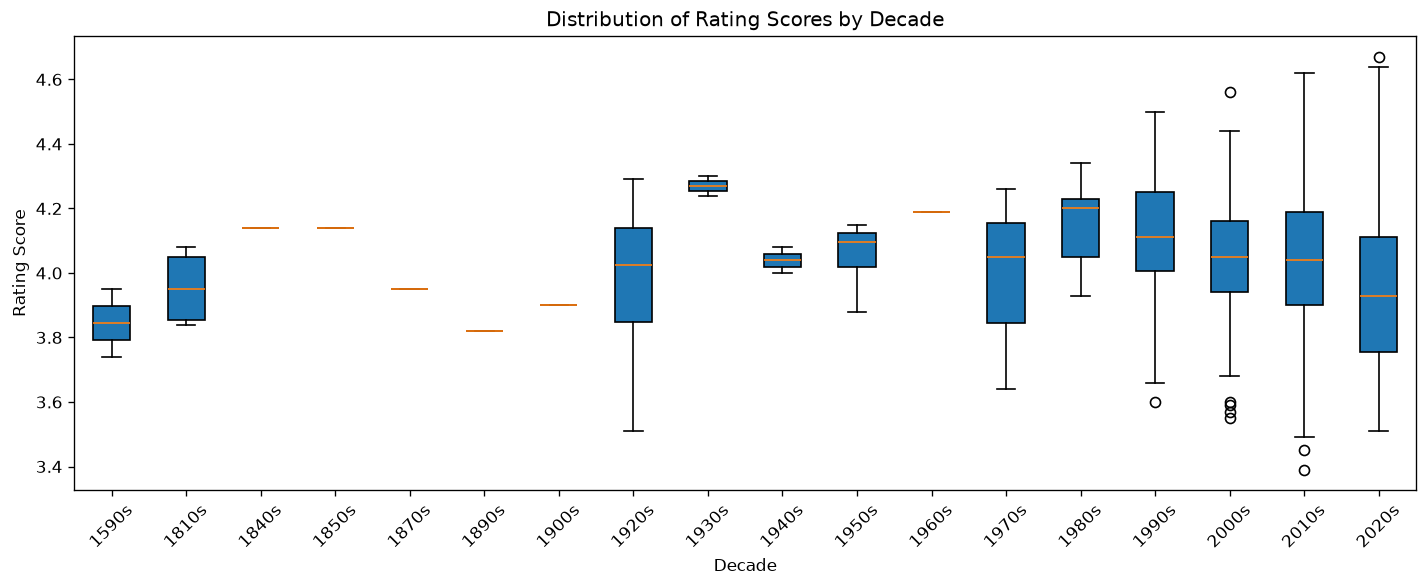

In [9]:
box_df = df.dropna(subset=["decade", "rating"]).copy()
box_df["decade_label"] = box_df["decade"].astype(int).astype(str) + "s"
decade_order = [f"{int(d)}s" for d in sorted(box_df["decade"].unique())]
grouped = [box_df.loc[box_df["decade_label"] == d, "rating"].values for d in decade_order]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(grouped, tick_labels=decade_order, patch_artist=True)
ax.set_xlabel("Decade")
ax.set_ylabel("Rating Score")
ax.set_title("Distribution of Rating Scores by Decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7b. Top authors by average rating

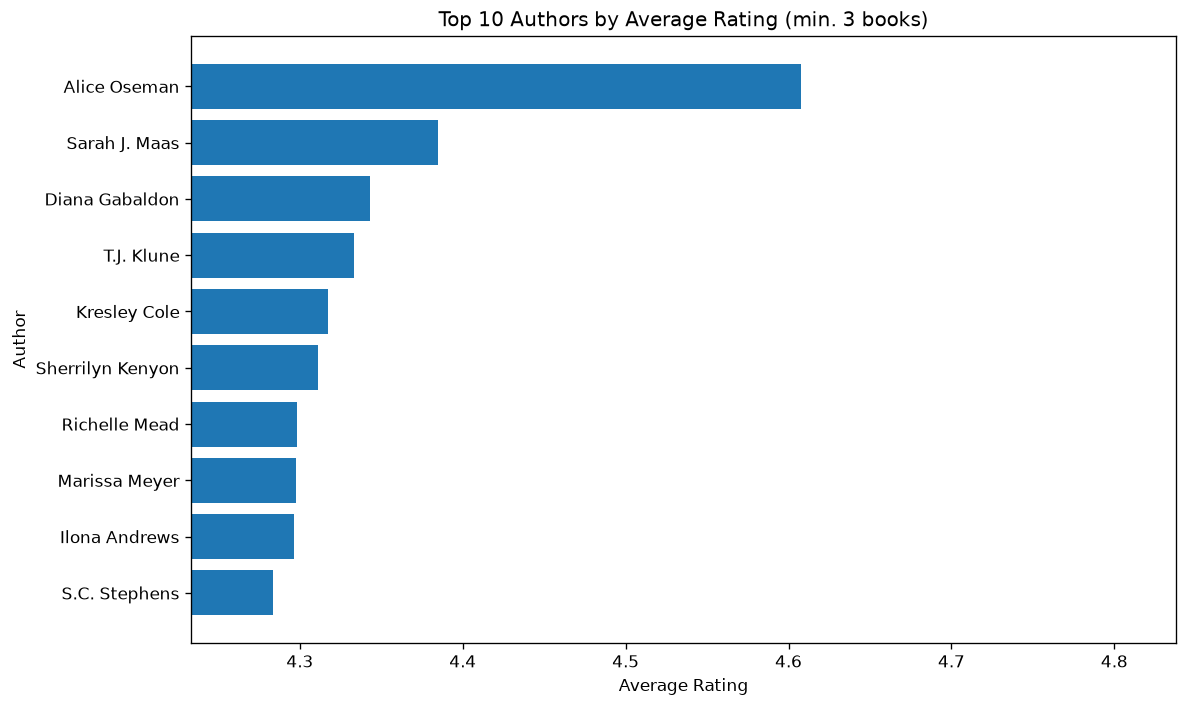

In [10]:
# Authors with at least 3 books for a stable average
top_avg = (
    df.dropna(subset=["author_name", "rating"])
    .groupby("author_name")
    .filter(lambda g: len(g) >= 3)
    .groupby("author_name", as_index=False)["rating"]
    .mean()
    .sort_values("rating", ascending=False)
    .head(10)
    .sort_values("rating", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_avg["author_name"], top_avg["rating"])
ax.set_xlabel("Average Rating")
ax.set_ylabel("Author")
ax.set_title("Top 10 Authors by Average Rating (min. 3 books)")
ax.set_xlim(left=top_avg["rating"].min() - 0.05)
plt.tight_layout()
plt.show()

## 8. Export Analysis Outputs

Produce the two required output files (`decade_releases.png`, `top_authors.png`).

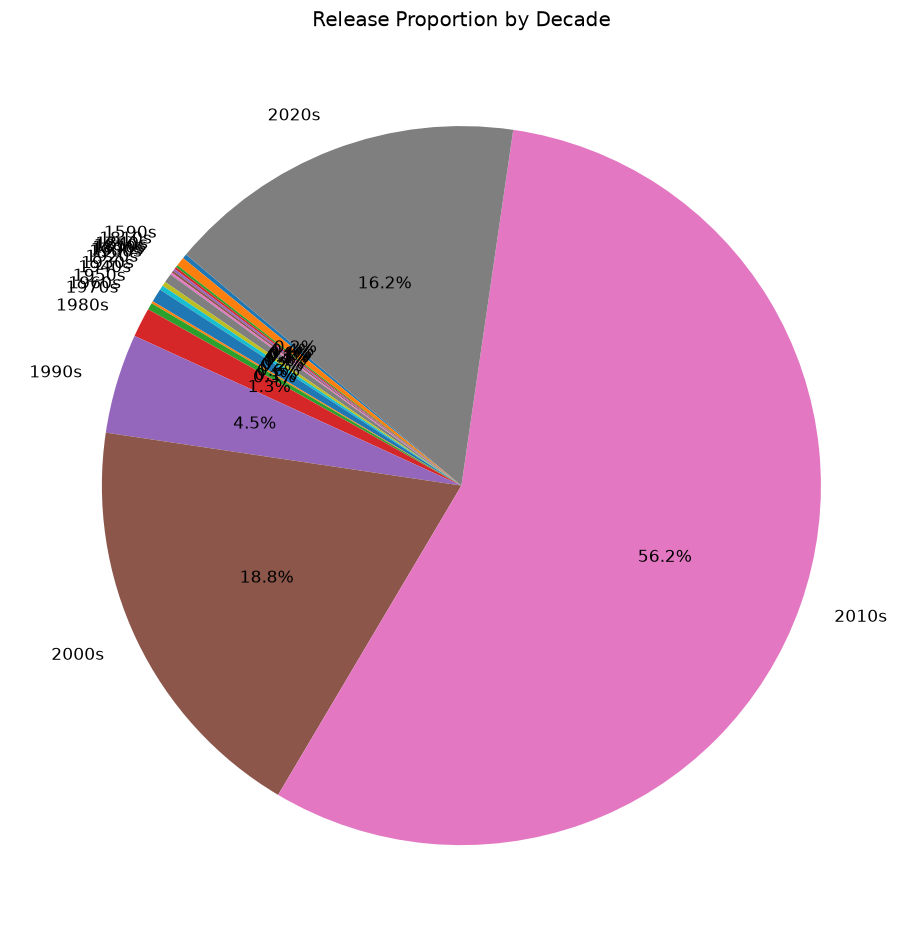

Saved decade_releases.png


In [11]:
# --- decade_releases.png ---
years = df["year"].dropna().astype(int)
decades = (years // 10) * 10
counts = decades.value_counts().sort_index()
labels = [f"{d}s" for d in counts.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=140)
ax.set_title("Release Proportion by Decade")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "decade_releases.png", dpi=150)
plt.show()
print("Saved decade_releases.png")

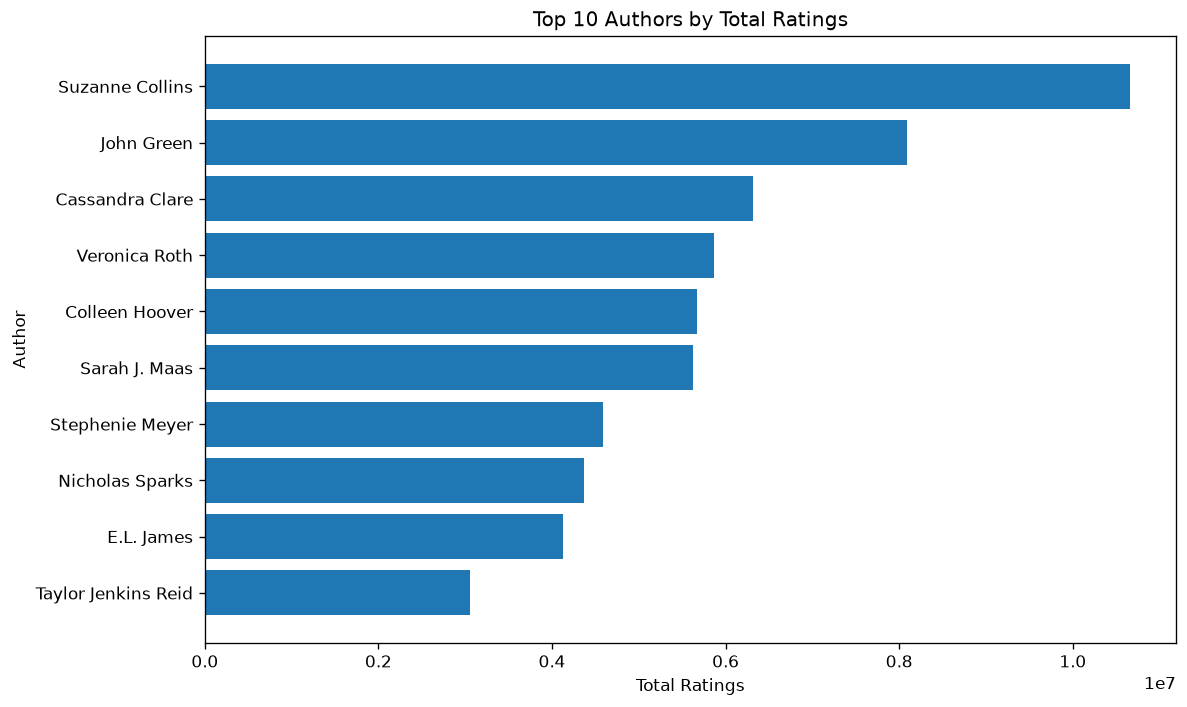

Saved top_authors.png


In [12]:
# --- top_authors.png ---
top_authors = (
    df.dropna(subset=["author_name", "ratings"])
    .groupby("author_name", as_index=False)["ratings"]
    .sum()
    .sort_values(by="ratings", ascending=False)
    .head(10)
    .sort_values(by="ratings", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_authors["author_name"], top_authors["ratings"])
ax.set_xlabel("Total Ratings")
ax.set_ylabel("Author")
ax.set_title("Top 10 Authors by Total Ratings")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "top_authors.png", dpi=150)
plt.show()
print("Saved top_authors.png")